In [1]:
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from functools import partial

from scipy.special import erfc

from classy import Class
from py21cmfast.inputs import global_params 
import py21cmfast as p21c

-----------------------------------------------------
SarahLibanore: developed f_nl, C files updated with IC and fcoll in Lidz approximation and DAlosio on 09/22/2025
-----------------------------------------------------


Set cosmo params

In [2]:
cosmo_params_fNL = {"hlittle": 0.6736, # hubble parameter
                "OMb": 0.0493, # baryon density
                "OMm": 0.3153, # matter (CDM+baryon) density
                "A_s": 2.1e-9, # amplitude of the primordial fluctuations
                "POWER_INDEX": 0.9649, # spectral index of the primordial spectrum
                "tau_reio": 0.0544, # optical depth to reionization
                "F_NL":300., # LOCAL NON GAUSSIANITY
                }

Run CLASS -- note that in this case the computation is always done in the gaussian case!

In [ ]:
CLASS_params = {}
CLASS_params['h'] = cosmo_params_fNL['hlittle']
CLASS_params['Omega_cdm'] = cosmo_params_fNL['OMm'] - cosmo_params_fNL['OMb']
CLASS_params['Omega_b'] = cosmo_params_fNL['OMb']
CLASS_params['A_s'] = cosmo_params_fNL['A_s']
CLASS_params['n_s'] = cosmo_params_fNL['POWER_INDEX']
CLASS_params['output'] = 'tCl,pCl,lCl,mTk,vTk,mPk'
CLASS_params['lensing'] = 'yes'
CLASS_params['z_pk'] = 1087.
CLASS_params['l_max_scalars'] = 3000
# We need to run CLASS for very large wavenumbers. This is required for computing sigma(M) and the HMF
CLASS_params['P_k_max_1/Mpc'] = 1200.

# Run CLASS!
CLASS_OUTPUT = Class()
CLASS_OUTPUT.set(CLASS_params)
CLASS_OUTPUT.compute()

Compute transfer function

In [ ]:
Transfer_0 = CLASS_OUTPUT.get_transfer(z=0.)
k_CLASS = Transfer_0['k (h/Mpc)'][:]*cosmo_params_fNL['hlittle'] # 1/Mpc
T_m_CLASS = Transfer_0['d_tot'][:]
k_output = pow(10.,np.array(global_params.LOG_K_ARR_FOR_TRANSFERS)) # 1/Mpc
T_m_0 = p21c.generate_ICs.Interpolate_transfer(T_m_CLASS,k_CLASS,k_output)

Text(0, 0.5, 'T(k)')

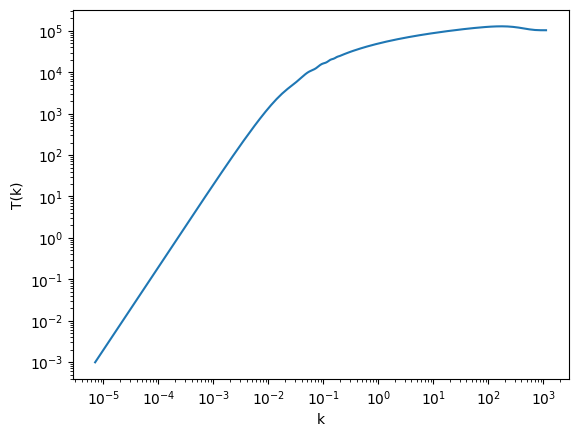

In [6]:
plt.loglog(k_output,T_m_0)
plt.xlabel('k')
plt.ylabel('T(k)')

Compute growth factor

In [11]:
z = np.linspace(0,10)
D = np.vectorize(CLASS_OUTPUT.scale_independent_growth_factor)(z)

Text(0, 0.5, 'D(z)')

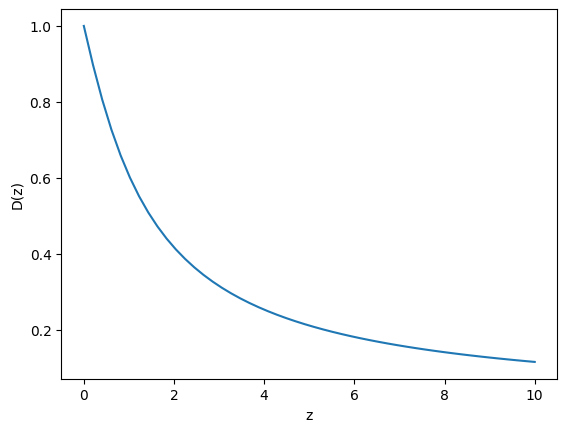

In [12]:
plt.plot(z,D)
plt.xlabel('z')
plt.ylabel('D(z)')